# Chowdeck — Machine Learning: Dự đoán Đơn Giá trị cao

Xây dựng model Random Forest Classifier dự đoán 1 đơn hàng có thuộc nhóm giá trị cao hay không, dựa trên các yếu tố ngữ cảnh (nhà hàng, nhóm món, thời gian, khu vực, rating). Mục tiêu: tìm yếu tố nào ảnh hưởng mạnh nhất đến giá trị đơn hàng khi xét đồng thời (đa biến), bổ sung cho phân tích tương quan đơn biến ở Bước 6.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import shap

sns.set_style("whitegrid")
pd.set_option('display.max_columns', 50)

## ĐƯỜNG DẪN

In [2]:
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd().resolve().parent
CLEAN_PATH = BASE_DIR / 'data' / 'clean' / 'chowdeck_clean.csv'
CHARTS_DIR = BASE_DIR / 'outputs' / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

## 1. ĐỌC DỮ LIỆU ĐÃ LÀM SẠCH

In [3]:
df = pd.read_csv(CLEAN_PATH, parse_dates=['Order Received', 'Order Delivered'])
print("Shape dữ liệu:", df.shape)

Shape dữ liệu: (3061, 33)


## 2. TẠO BIẾN MỤC TIÊU (TARGET): ĐƠN GIÁ TRỊ CAO HAY THẤP

In [4]:
median_subtotal = df['Sub Total'].median()
df['high_value'] = (df['Sub Total'] > median_subtotal).astype(int)
print(f"\nNgưỡng median Sub Total: ₦{median_subtotal:,.0f}")
print(f"Phân bố target: {df['high_value'].value_counts().to_dict()} "
      f"(0 = giá trị thấp, 1 = giá trị cao)")


Ngưỡng median Sub Total: ₦5,000
Phân bố target: {0: 1685, 1: 1376} (0 = giá trị thấp, 1 = giá trị cao)


## 3. CHỌN FEATURES (CHỈ DÙNG YẾU TỐ NGỮ CẢNH, KHÔNG DÙNG UNIT PRICE/QUANTITY)

In [5]:
feature_cols_categorical = ['Order Category', 'Shop Name', 'order_dayofweek', 'Delivery Location']
feature_cols_numeric = ['order_hour', 'Distance (km)', 'Rating', 'prep_time_min', 'delivery_time_min']

model_df = df[feature_cols_categorical + feature_cols_numeric + ['high_value']].dropna()
print(f"\nSố dòng dùng để train (sau khi bỏ dòng thiếu dữ liệu): {len(model_df)} / {len(df)}")


Số dòng dùng để train (sau khi bỏ dòng thiếu dữ liệu): 3061 / 3061


## 4. MÃ HÓA BIẾN PHÂN LOẠI (Label Encoding)

In [6]:
encoders = {}
for col in feature_cols_categorical:
    le = LabelEncoder()
    model_df[col + '_enc'] = le.fit_transform(model_df[col])
    encoders[col] = le

feature_cols_final = [c + '_enc' for c in feature_cols_categorical] + feature_cols_numeric
X = model_df[feature_cols_final]
y = model_df['high_value']

## 5. CHIA TRAIN/TEST (80/20)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train)} dòng | Test: {len(X_test)} dòng")


Train: 2448 dòng | Test: 613 dòng


## 6. HUẤN LUYỆN MODEL RANDOM FOREST

In [8]:
model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 T

## 7. ĐÁNH GIÁ MODEL


=== KẾT QUẢ MODEL CHOWDECK ===
Accuracy:  0.775
Precision: 0.825
Recall:    0.634
F1-score:  0.717

Baseline (luôn đoán lớp đa số): 0.550 | Model: 0.775 | Model hơn baseline 22.5 điểm %


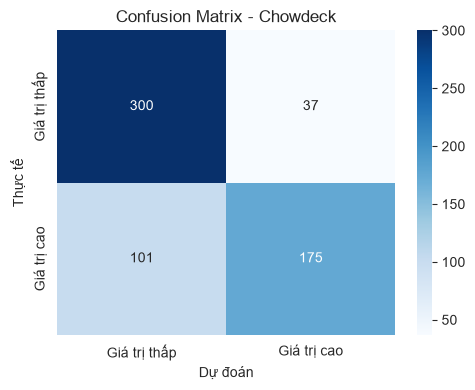

In [9]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n=== KẾT QUẢ MODEL CHOWDECK ===")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")
baseline_major = max(y_test.mean(), 1 - y_test.mean())   # baseline đúng: luôn đoán lớp đa số
print(f"\nBaseline (luôn đoán lớp đa số): {baseline_major:.3f} | Model: {acc:.3f} "
      f"| Model hơn baseline {100*(acc-baseline_major):.1f} điểm %")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Giá trị thấp', 'Giá trị cao'],
            yticklabels=['Giá trị thấp', 'Giá trị cao'])
plt.title('Confusion Matrix - Chowdeck')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_ml_confusion_matrix_chowdeck.png', dpi=120)
plt.show()
plt.close()

## 8. FEATURE IMPORTANCE - KẾT QUẢ QUAN TRỌNG NHẤT


=== Feature Importance (Chowdeck) ===
Order Category_enc       0.353768
Shop Name_enc            0.208482
Distance (km)            0.096503
delivery_time_min        0.087627
order_hour               0.067623
prep_time_min            0.064285
Delivery Location_enc    0.046979
order_dayofweek_enc      0.043942
Rating                   0.030790
dtype: float64


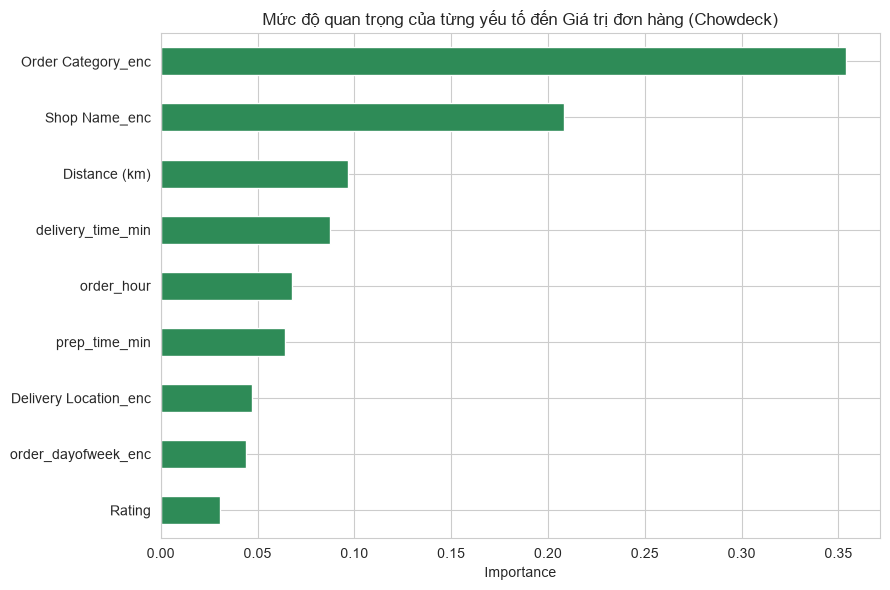

In [10]:
importance = pd.Series(model.feature_importances_, index=feature_cols_final).sort_values(ascending=False)
print("\n=== Feature Importance (Chowdeck) ===")
print(importance)

plt.figure(figsize=(9, 6))
importance.plot(kind='barh', color='seagreen')
plt.title('Mức độ quan trọng của từng yếu tố đến Giá trị đơn hàng (Chowdeck)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_ml_feature_importance_chowdeck.png', dpi=120)
plt.show()
plt.close()


## 9. CROSS-VALIDATION (5-FOLD) - KIỂM TRA ĐỘ ỔN ĐỊNH CỦA MODEL

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print("\n=== Cross-Validation (5-fold) - Chowdeck ===")
print(f"Accuracy từng fold: {np.round(cv_scores, 3)}")
print(f"Accuracy trung bình: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
print(f"So với Accuracy đo 1 lần trên Test set ({acc:.3f}): "
      f"{'nhất quán, đáng tin cậy' if abs(cv_scores.mean() - acc) < 0.05 else 'có chênh lệch, cần xem lại'}")


=== Cross-Validation (5-fold) - Chowdeck ===
Accuracy từng fold: [0.75  0.773 0.775 0.753 0.76 ]
Accuracy trung bình: 0.762 (+/- 0.010)
So với Accuracy đo 1 lần trên Test set (0.775): nhất quán, đáng tin cậy


## 5b. KIỂM TRA BỔ SUNG: BASELINE, ABLATION VÀ PERMUTATION IMPORTANCE

Mục đích: trả lời câu hỏi *model có học thêm được gì ngoài `Order Category` không?*
- **Baseline**: luôn đoán lớp đa số (không dùng feature nào).
- **Ablation**: huấn luyện lại với các bộ feature khác nhau, đo bằng 5-fold CV để so sánh công bằng.
- **Permutation importance**: đo mức giảm accuracy trên tập test khi xáo trộn từng feature (ít thiên lệch hơn `feature_importances_` kiểu impurity).

                                       Bộ feature  Accuracy CV (TB)   Std
                    Baseline: luôn đoán lớp đa số             0.550 0.000
                               Chỉ Order Category             0.765 0.010
                       Order Category + Shop Name             0.765 0.010
                   Bỏ Order Category và Shop Name             0.515 0.019
                                     Bỏ Shop Name             0.753 0.012
                    Bỏ prep_time và delivery_time             0.762 0.009
                  Đầy đủ feature (model hiện tại)             0.762 0.010
Đầy đủ feature, chỉ đơn timestamp hợp lệ (n=2191)             0.759 0.018


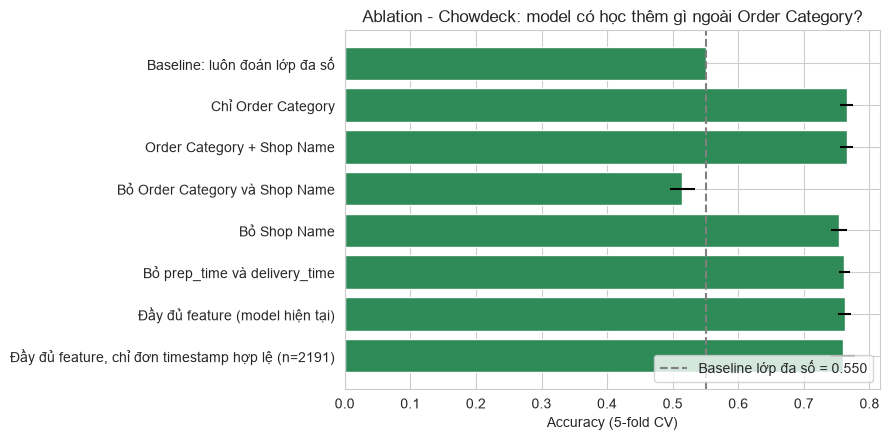

In [12]:
from sklearn.dummy import DummyClassifier

def cv_acc(cols, name, Xs=None, ys=None):
    Xs = X if Xs is None else Xs
    ys = y if ys is None else ys
    rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced')
    s = cross_val_score(rf, Xs[cols], ys, cv=cv, scoring='accuracy')
    return {'Bộ feature': name, 'Accuracy CV (TB)': s.mean(), 'Std': s.std()}

cat_enc, shop_enc = 'Order Category_enc', 'Shop Name_enc'
time_cols = ['prep_time_min', 'delivery_time_min']
rows = []

base = cross_val_score(DummyClassifier(strategy='most_frequent'), X, y, cv=cv, scoring='accuracy')
rows.append({'Bộ feature': 'Baseline: luôn đoán lớp đa số', 'Accuracy CV (TB)': base.mean(), 'Std': base.std()})
rows.append(cv_acc([cat_enc], 'Chỉ Order Category'))
rows.append(cv_acc([cat_enc, shop_enc], 'Order Category + Shop Name'))
rows.append(cv_acc([c for c in feature_cols_final if c not in (cat_enc, shop_enc)], 'Bỏ Order Category và Shop Name'))
rows.append(cv_acc([c for c in feature_cols_final if c != shop_enc], 'Bỏ Shop Name'))
rows.append(cv_acc([c for c in feature_cols_final if c not in time_cols], 'Bỏ prep_time và delivery_time'))
rows.append(cv_acc(feature_cols_final, 'Đầy đủ feature (model hiện tại)'))

# Chỉ dùng đơn có timestamp hợp lệ (≈ 28% đơn có timestamp sai thứ tự thì prep/delivery time bị nhiễu)
valid_mask = df.loc[X.index, 'time_sequence_valid'].astype(bool)
r = cv_acc(feature_cols_final, f'Đầy đủ feature, chỉ đơn timestamp hợp lệ (n={valid_mask.sum()})', X[valid_mask], y[valid_mask])
rows.append(r)

ablation_df = pd.DataFrame(rows)
print(ablation_df.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

plt.figure(figsize=(9, 4.5))
plt.barh(ablation_df['Bộ feature'], ablation_df['Accuracy CV (TB)'], xerr=ablation_df['Std'], color='seagreen')
plt.axvline(base.mean(), color='gray', linestyle='--', label=f'Baseline lớp đa số = {base.mean():.3f}')
plt.gca().invert_yaxis()
plt.xlabel('Accuracy (5-fold CV)')
plt.title('Ablation - Chowdeck: model có học thêm gì ngoài Order Category?')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_ml_ablation_chowdeck.png', dpi=120)
plt.show()
plt.close()

              feature  giảm accuracy (TB)    std
   Order Category_enc              0.1888 0.0223
        Shop Name_enc              0.0423 0.0083
  order_dayofweek_enc              0.0022 0.0025
           order_hour              0.0017 0.0031
        Distance (km)              0.0002 0.0030
               Rating             -0.0009 0.0024
        prep_time_min             -0.0025 0.0031
Delivery Location_enc             -0.0027 0.0032
    delivery_time_min             -0.0029 0.0030


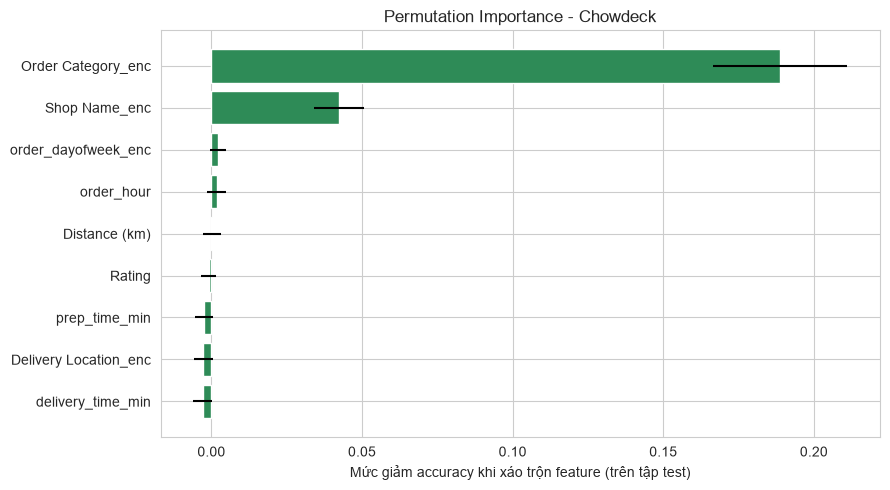

In [13]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(model, X_test, y_test, n_repeats=20, random_state=42, scoring='accuracy')
perm_df = (pd.DataFrame({'feature': feature_cols_final,
                         'giảm accuracy (TB)': perm.importances_mean,
                         'std': perm.importances_std})
             .sort_values('giảm accuracy (TB)', ascending=False))
print(perm_df.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

plt.figure(figsize=(9, 5))
plt.barh(perm_df['feature'], perm_df['giảm accuracy (TB)'], xerr=perm_df['std'], color='seagreen')
plt.gca().invert_yaxis()
plt.xlabel('Mức giảm accuracy khi xáo trộn feature (trên tập test)')
plt.title('Permutation Importance - Chowdeck')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_ml_permutation_importance_chowdeck.png', dpi=120)
plt.show()
plt.close()

**Cách đọc kết quả mục 5b:** nếu "Chỉ Order Category" đạt accuracy gần bằng hoặc cao hơn "Đầy đủ feature" thì model không học thêm được gì đáng kể ngoài nhóm món. Các feature khác (Rating, khu vực, thứ, giờ...) chỉ nên được đọc là *không có đóng góp rõ ràng*, không phải "ảnh hưởng yếu". Mọi kết quả vẫn chỉ là mối liên hệ, không phải quan hệ nhân quả.

## 10. SHAP VALUES - GIẢI THÍCH CHIỀU ẢNH HƯỞNG CỦA TỪNG YẾU TỐ

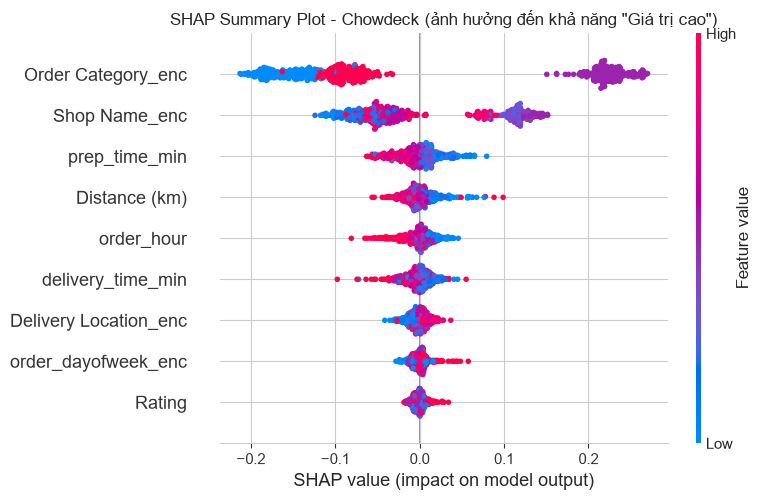


=== HOÀN TẤT MODEL ML CHOWDECK (đã nâng cấp: Cross-Validation + SHAP) ===


In [14]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap_values_high = shap_values[:, :, 1]

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values_high, X_test, feature_names=feature_cols_final, show=False)
plt.title('SHAP Summary Plot - Chowdeck (ảnh hưởng đến khả năng "Giá trị cao")')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_ml_shap_summary_chowdeck.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()

print("\n=== HOÀN TẤT MODEL ML CHOWDECK (đã nâng cấp: Cross-Validation + SHAP) ===")